In [6]:

using PVlib

using HTTP
using JSON
using DataFrames
using Dates
using CSV
using Plots
using Statistics
using LinearAlgebra
using TimeZones

using Optim
using Zygote
using FiniteDiff
using ForwardDiff

using MAT

In [8]:
# create function that support initial tilt input
function dc_power_return(latitude, longitude, altitude, 
                        initial_tilt, initial_azimuth, weather_data, sol_position, 
                        pv_module, pv_inverter, WEC_response, panel, obstacle, 
                        n_cells_per_column, albedo, sim_time)
    
    panel_tilt, panel_azimuth = panel_tilt_azimuth(WEC_response, initial_tilt, initial_azimuth)

    total_irradiance = get_total_irradiance(panel_tilt, panel_azimuth, weather_data, sol_position, albedo, sim_time) 
    cell_temp = rolling_average_sapm_cell_temperature(total_irradiance, weather_data)

    effective_irradiance = sapm_effective_irradiance(total_irradiance, pv_module, sol_position, panel_tilt, panel_azimuth, altitude)

    f_shade = get_shaded_fraction(sol_position, panel_tilt, panel_azimuth, panel, obstacle, nx=10, ny=10)
    power_norm = get_power_norm(total_irradiance, f_shade, n_cells_per_column)

    dc_components_shaded = sapm_dc_components_shaded(pv_module, effective_irradiance, cell_temp, power_norm)
    ac_power = sandia_ac_power(pv_inverter, dc_components_shaded)
    return getfield.(dc_components_shaded, :p_mp)
end

dc_power_return (generic function with 1 method)

In [9]:
data = matread("pioneer_6dof_response_wave1.mat")
time = vec(data["time"])
WEC_response = data["WEC_response"]

dt = time[2] - time[1]
T = time[end] + dt
time3 = vcat(time, time .+ T, time .+ (2*T))
WEC_response3 = vcat(WEC_response, WEC_response, WEC_response)

39003×6 Matrix{Float64}:
 -8.83514  -26.697   0.298      0.0          -0.0           0.0
 -8.83514  -26.697   0.30334    9.70905e-10  -2.99434e-8    2.69381e-10
 -8.83514  -26.697   0.3189    -6.88928e-8   -9.36079e-8    1.0716e-9
 -8.83514  -26.697   0.343368  -1.63306e-7   -2.03642e-7    2.88071e-9
 -8.83514  -26.697   0.374012  -4.48885e-8   -4.3755e-7     6.38232e-9
 -8.83514  -26.697   0.407384   3.75152e-7   -8.28285e-7    1.05373e-8
 -8.83513  -26.697   0.440324   1.0706e-6    -1.38096e-6    1.69084e-8
 -8.83513  -26.697   0.470121   2.05582e-6   -2.1206e-6     2.5734e-8
 -8.83513  -26.697   0.494816   3.45079e-6   -3.11331e-6    3.69899e-8
 -8.83513  -26.697   0.512905   5.46931e-6   -4.46141e-6    5.21309e-8
 -8.83513  -26.697   0.523388   8.38691e-6   -6.28279e-6    6.96049e-8
 -8.83513  -26.697   0.52606    1.26132e-5   -8.74278e-6    8.72951e-8
 -8.83514  -26.697   0.521401   1.88153e-5   -1.20837e-5    1.07294e-7
  ⋮                                                         

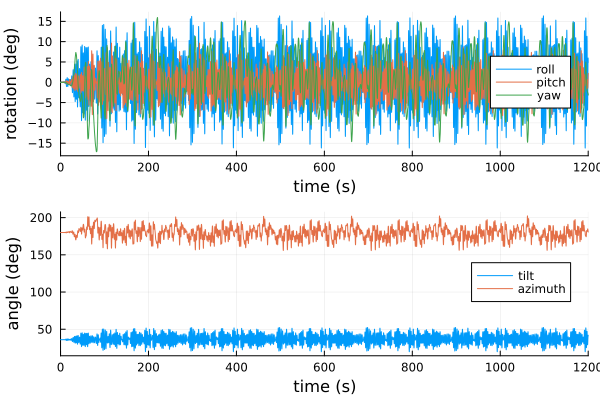

In [10]:
# load in WEC respponse
data = matread("pioneer_6dof_response_wave1.mat")
time = vec(data["time"])
WEC_response = data["WEC_response"]

latitude = 35.95
initial_tilt = latitude
initial_azimuth = 180
initial_yaw = 0
panel_tilt, panel_azimuth = panel_tilt_azimuth(WEC_response, initial_tilt, initial_azimuth, initial_yaw)

t = time                      # length N
x = WEC_response[:,1]; y = WEC_response[:,2]; z = WEC_response[:,3]
roll  = WEC_response[:,4]
pitch = WEC_response[:,5]
yaw   = WEC_response[:,6]

# 2) Rotational motions
p2 = plot(t, roll*180/pi,  label="roll",  xlabel="time (s)", ylabel="rotation (deg)",xlims=(0, 1200),)
plot!(p2, t, pitch*180/pi, label="pitch")
plot!(p2, t, yaw*180/pi,   label="yaw")

# 3) Panel angles
p3 = plot(t, panel_tilt, label="tilt", xlabel="time (s)", ylabel="angle (deg)", xlims=(0, 1200),)
plot!(p3, t, panel_azimuth,   label="azimuth")

plot(p2, p3, layout=(2,1), legend=:right)

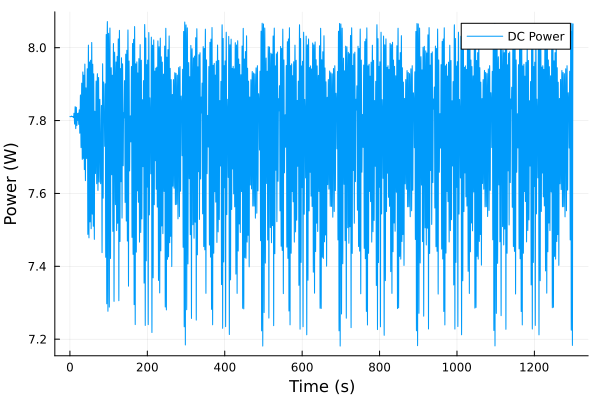

In [11]:
# location and installation details for pioneer
latitude = 35.95
longitude = -75.125
altitude = 0.0 # m
api_key = "E52b7mqeTWLigj2xF5Bn4n6Mm87ecm5LFFeYh4US" # from NLR
email = "jtgrasb@sandia.gov"
start_monthday=(1, 1)
end_monthday=(1, 1)
number_of_panels = 1
initial_azimuth = 180.0
initial_tilt = latitude
module_name = "Kyocera Solar KC40T [2008 (E)]" #"Canadian Solar CS5P-220M [ 2009]" 
inverter_name = "Enphase Energy Inc : M175-24-208-Sxx [208V]" #"ABB: MICRO-0.25-I-OUTD-US-208 [208V]" # 175 W is well above max power needed
pv_module = read_solar_module(module_name)
pv_inverter = read_solar_inverter(inverter_name);

# create example WEC resposne
#time = range(0, 500, 1001)
#amplitude = [1, 0.1, 1, 0.1, 1, 0.2]
#period = 10 # seconds
#ω = 2π / period
#WEC_response = amplitude' .* sin.(ω .* time)

# installation characteristics
panel = Panel(0.526, 0.652) # panel dimensnions in meters (Kyocera Solar KC40T [2008 (E)])
# A box above the panel
obstacle = BoxObstacle(
    -0.5, 0.5,   # x-range
    -0.3, 0.3,     # y-range
    0.4, 0.5   # z-range
)
n_cells_per_column = 9

# import weather data, calculate solar position, and corresponding albedo
weather_data = get_meteorological_data_nsrdb(latitude, longitude, api_key, email, start_monthday, end_monthday, false)
weather_data = weather_data[12] # just use the 12th hour for this simulation
sol_position = get_solar_position(latitude, longitude, altitude, weather_data)
albedo = get_ocean_surface_albedo(weather_data, sol_position)

dc_power = dc_power_return(latitude, longitude, altitude, initial_tilt, initial_azimuth, weather_data, sol_position, pv_module, pv_inverter, WEC_response, panel, obstacle, n_cells_per_column, albedo, time)

plot(time, dc_power, label="DC Power", xlabel="Time (s)", ylabel="Power (W)", legend=:topright)


In [12]:
function objective(latitude, longitude, altitude, 
                        installation_tilt, installation_azimuth, weather_data, sol_position, 
                        pv_module, pv_inverter, WEC_response, panel, obstacle, 
                        n_cells_per_column, albedo, sim_time)

    avg_power = mean(dc_power_return(latitude, longitude, altitude, 
                        installation_tilt, installation_azimuth, weather_data, sol_position, 
                        pv_module, pv_inverter, WEC_response, panel, obstacle, 
                        n_cells_per_column, albedo, sim_time))
    return -avg_power
end

installation_tilt = latitude
installation_azimuth = 180.0

check_mean_power = objective(latitude, longitude, altitude, installation_tilt, installation_azimuth, weather_data, sol_position, pv_module, pv_inverter, WEC_response, panel, obstacle, n_cells_per_column, albedo, time)
println("Mean power for installation tilt: ", -check_mean_power)

mean_power = orientation -> objective(latitude, longitude, altitude, orientation[1], installation_azimuth, weather_data, sol_position, pv_module, pv_inverter, WEC_response, panel, obstacle, n_cells_per_column, albedo, time)

Mean power for installation tilt: 7.756580302086749


#2 (generic function with 1 method)

In [ ]:

# optimize installation tilt and azimuth
mean_power = orientation -> objective(latitude, longitude, altitude, orientation[1], orientation[2], weather_data, sol_position, pv_module, pv_inverter, WEC_response, panel, obstacle, n_cells_per_column, albedo, time)

function g!(G, orientation)
    ForwardDiff.gradient!(G, mean_power, orientation)
end

surface_tilt = latitude
x0 = [surface_tilt, 180.0]
x0 = [10.0, 60.0]
lower = [0.0, 0.0]
upper = [90.0, 360.0]

res = optimize(mean_power, g!, lower, upper, x0, Fminbox(BFGS()))

println("Optimal installation tilt: ", res.minimizer[1])
println("Optimal installation azimuth: ", res.minimizer[2])
println("Maximum mean power: ", -res.minimum)

Optimal installation tilt: 0.02445854827226634


LoadError: BoundsError: attempt to access 1-element Vector{Float64} at index [2]